In [1]:
#imports
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

os.makedirs("../results", exist_ok=True)

Using: cpu


In [3]:
TEST_PATH = "../data/DATASET/test"

IMG_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 7

cnn_model_path = "../models/emotion_cnn_baseline.pth"
resnet_model_path = "../models/emotion_resnet34_transfer.pth"

In [4]:
class_names = {
    0: "surprise",
    1: "fear",
    2: "disgust",
    3: "happy",
    4: "sad",
    5: "angry",
    6: "neutral"
}

target_names = list(class_names.values())

print(target_names)

['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry', 'neutral']


In [5]:
resnet_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

cnn_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [6]:
resnet_test_dataset = datasets.ImageFolder(TEST_PATH, transform=resnet_test_transform)
cnn_test_dataset = datasets.ImageFolder(TEST_PATH, transform=cnn_test_transform)

resnet_test_loader = DataLoader(
    resnet_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

cnn_test_loader = DataLoader(
    cnn_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Test images:", len(resnet_test_dataset))
print("Classes:", resnet_test_dataset.classes)
print("Class to index:", resnet_test_dataset.class_to_idx)

Test images: 3068
Classes: ['1', '2', '3', '4', '5', '6', '7']
Class to index: {'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6}


In [7]:
class EmotionCNNBaseline(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [8]:
cnn_model = EmotionCNNBaseline().to(device)
cnn_model.load_state_dict(torch.load(cnn_model_path, map_location=device))
cnn_model.eval()

resnet_model = models.resnet34(pretrained=False)
resnet_model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(resnet_model.fc.in_features, NUM_CLASSES)
)

resnet_model.load_state_dict(torch.load(resnet_model_path, map_location=device))
resnet_model = resnet_model.to(device)
resnet_model.eval()

print("Both models loaded successfully")

C:\Users\kusha\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\kusha\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Both models loaded successfully


In [9]:
def evaluate_model(model, data_loader):
    all_labels = []
    all_predictions = []

    model.eval()

    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_X)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(batch_y.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_predictions)

    return np.array(all_labels), np.array(all_predictions), accuracy

In [10]:
cnn_labels, cnn_predictions, cnn_accuracy = evaluate_model(cnn_model, cnn_test_loader)

print("CNN Baseline Accuracy:", cnn_accuracy)
print()
print(classification_report(
    cnn_labels,
    cnn_predictions,
    target_names=target_names,
    zero_division=0
))

CNN Baseline Accuracy: 0.6551499348109517

              precision    recall  f1-score   support

    surprise       0.69      0.75      0.72       329
        fear       0.20      0.64      0.31        74
     disgust       0.27      0.57      0.37       160
       happy       0.94      0.65      0.77      1185
         sad       0.64      0.65      0.65       478
       angry       0.51      0.69      0.59       162
     neutral       0.70      0.64      0.66       680

    accuracy                           0.66      3068
   macro avg       0.57      0.66      0.58      3068
weighted avg       0.74      0.66      0.68      3068



In [11]:
resnet_labels, resnet_predictions, resnet_accuracy = evaluate_model(resnet_model, resnet_test_loader)

print("ResNet34 Transfer Learning Accuracy:", resnet_accuracy)
print()
print(classification_report(
    resnet_labels,
    resnet_predictions,
    target_names=target_names,
    zero_division=0
))

ResNet34 Transfer Learning Accuracy: 0.8308344198174706

              precision    recall  f1-score   support

    surprise       0.76      0.88      0.81       329
        fear       0.66      0.45      0.53        74
     disgust       0.55      0.54      0.55       160
       happy       0.96      0.90      0.93      1185
         sad       0.82      0.79      0.80       478
       angry       0.73      0.78      0.75       162
     neutral       0.78      0.84      0.81       680

    accuracy                           0.83      3068
   macro avg       0.75      0.74      0.74      3068
weighted avg       0.83      0.83      0.83      3068



In [12]:
cnn_report = classification_report(
    cnn_labels,
    cnn_predictions,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

resnet_report = classification_report(
    resnet_labels,
    resnet_predictions,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

pd.DataFrame(cnn_report).transpose().to_csv("../results/emotion_cnn_baseline_classification_report.csv")
pd.DataFrame(resnet_report).transpose().to_csv("../results/emotion_resnet34_transfer_classification_report.csv")

print("Classification reports saved")

Classification reports saved


In [13]:
def plot_confusion_matrix(labels, predictions, title, save_path):
    cm = confusion_matrix(labels, predictions)

    plt.figure(figsize=(8, 6))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks(ticks=np.arange(len(target_names)), labels=target_names, rotation=45)
    plt.yticks(ticks=np.arange(len(target_names)), labels=target_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

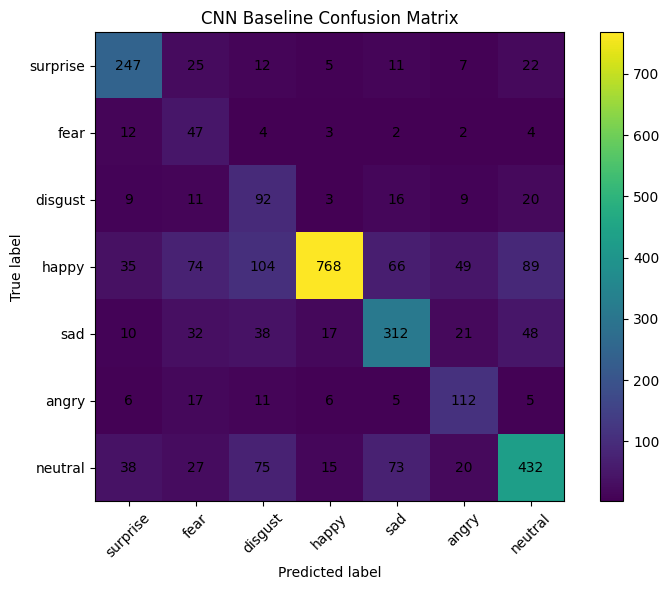

In [14]:
plot_confusion_matrix(
    cnn_labels,
    cnn_predictions,
    "CNN Baseline Confusion Matrix",
    "../results/emotion_cnn_baseline_confusion_matrix.png"
)

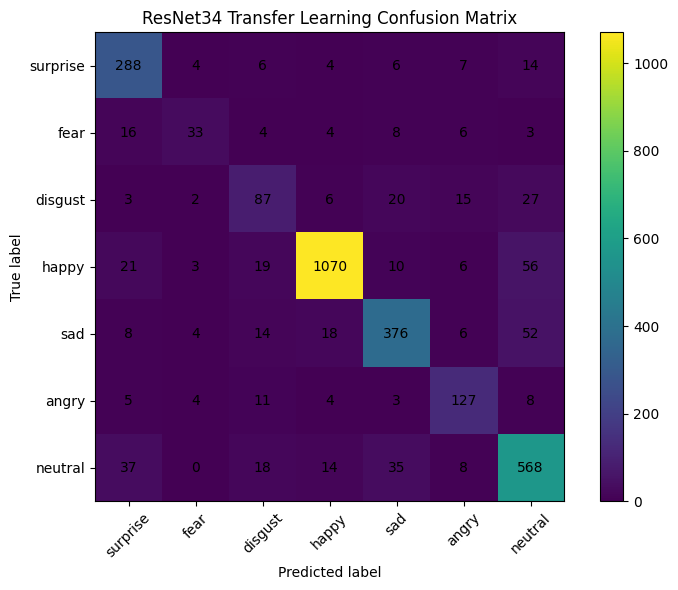

In [15]:
plot_confusion_matrix(
    resnet_labels,
    resnet_predictions,
    "ResNet34 Transfer Learning Confusion Matrix",
    "../results/emotion_resnet34_transfer_confusion_matrix.png"
)

In [16]:
model_comparison = pd.DataFrame({
    "Model": [
        "CNN Baseline",
        "ResNet34 Transfer Learning"
    ],
    "Training Approach": [
        "Trained from scratch",
        "Transfer learning with partial fine-tuning"
    ],
    "Accuracy": [
        cnn_accuracy,
        resnet_accuracy
    ]
})

model_comparison

,Model,Training Approach,Accuracy
0,CNN Baseline,Trained from scratch,0.655150
1,ResNet34 Transfer Learning,Transfer learning with partial fine-tuning,0.830834


In [17]:
model_comparison.to_csv("../results/emotion_model_comparison.csv", index=False)

print("Model comparison saved")

Model comparison saved


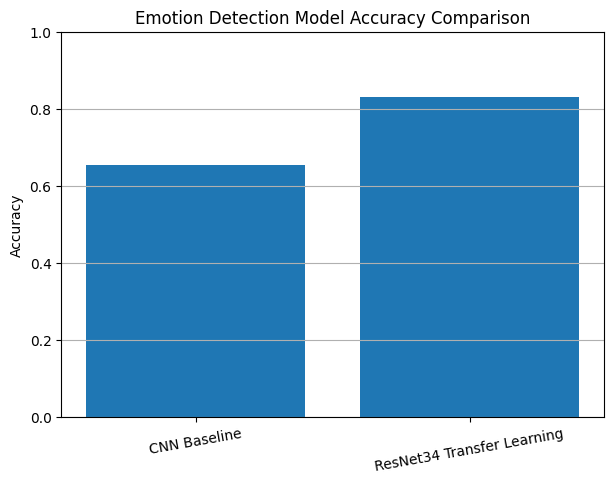

In [18]:
plt.figure(figsize=(7, 5))
plt.bar(model_comparison["Model"], model_comparison["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Emotion Detection Model Accuracy Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=10)
plt.grid(axis="y")

plt.savefig("../results/emotion_model_accuracy_comparison.png", bbox_inches="tight")
plt.show()

In [19]:
best_model_name = model_comparison.sort_values("Accuracy", ascending=False).iloc[0]["Model"]
best_model_acc = model_comparison.sort_values("Accuracy", ascending=False).iloc[0]["Accuracy"]

print(f"Best model: {best_model_name}")
print(f"Best accuracy: {best_model_acc:.3f}")

print()
print("Conclusion:")
print("The CNN baseline was trained from scratch and used as the comparison model.")
print("The ResNet34 transfer learning model achieved higher accuracy, so it was selected as the final emotion detection model.")

Best model: ResNet34 Transfer Learning
Best accuracy: 0.831

Conclusion:
The CNN baseline was trained from scratch and used as the comparison model.
The ResNet34 transfer learning model achieved higher accuracy, so it was selected as the final emotion detection model.
